In [2]:
import re
from dataclasses import dataclass
from pathlib import Path

@dataclass
class Datapoint:
    timestamp: int
    value: int
    acceleration: float
    gyroscope: float
    sound_detected: int

@dataclass
class Test:
    label: str | None
    datapoints: list[Datapoint]

def parse_data(filename: str | Path = 'data_collected.txt') -> list[Test]:
    text = Path(filename).read_text(encoding='utf-8')
    blocks = re.split(r'(?:\r?\n){3,}', text.strip())
    tests = []
    for block in blocks:
        datapoints, label = [], None
        for line_number, raw_line in enumerate(block.splitlines(), start=1):
            line = raw_line.strip()
            if not line:
                continue
            csv_part, separator, comment = line.partition('//')
            fields = [field.strip() for field in csv_part.split(',')]
            if len(fields) != 5 or any(not field for field in fields):
                raise ValueError(f'Invalid CSV row at block line {line_number}: {raw_line!r}')
            try:
                datapoints.append(Datapoint(int(fields[0]), int(fields[1]), float(fields[2]), float(fields[3]), int(fields[4])))
            except ValueError as error:
                raise ValueError(f'Invalid numeric value at block line {line_number}: {raw_line!r}') from error
            if len(datapoints) == 1 and separator:
                label = comment.strip() or None
        if datapoints:
            tests.append(Test(label, datapoints))
    return tests

tests = parse_data()
print(f'Parsed {len(tests)} tests and {sum(len(test.datapoints) for test in tests)} datapoints.')

Parsed 10 tests and 1027 datapoints.


In [3]:
for test in tests:
    for datapoint in test.datapoints:
        # errrr
        print(f"timestamp: {datapoint.timestamp}, value: {datapoint.value}, acceleration: {datapoint.acceleration}, gyroscope: {datapoint.gyroscope}, sound_detected: {datapoint.sound_detected}")

timestamp: 8026, value: 0, acceleration: 10.68, gyroscope: 25.94, sound_detected: 550
timestamp: 8066, value: 0, acceleration: 10.7, gyroscope: 27.95, sound_detected: 0
timestamp: 8105, value: 0, acceleration: 10.5, gyroscope: 20.71, sound_detected: 1108
timestamp: 8144, value: 0, acceleration: 11.08, gyroscope: 15.94, sound_detected: 0
timestamp: 8183, value: 0, acceleration: 10.48, gyroscope: 19.85, sound_detected: 468
timestamp: 8222, value: 0, acceleration: 10.12, gyroscope: 17.67, sound_detected: 575
timestamp: 8261, value: 0, acceleration: 10.03, gyroscope: 12.26, sound_detected: 264
timestamp: 8300, value: 0, acceleration: 9.8, gyroscope: 7.75, sound_detected: 383
timestamp: 8339, value: 0, acceleration: 9.99, gyroscope: 7.99, sound_detected: 0
timestamp: 8378, value: 0, acceleration: 9.64, gyroscope: 9.69, sound_detected: 572
timestamp: 8417, value: 0, acceleration: 9.62, gyroscope: 9.83, sound_detected: 320
timestamp: 8456, value: 0, acceleration: 9.78, gyroscope: 10.42, sound

1. FALL FORWARDS MATT
2. FALL SIDEWAYS MATT
3. SIT ON CHAIR
4. SIT ON COUCH
5. CHAIR TEST 3
6. LIGHT SHAKING ?????
7. FALL FORWARDS YI AN
8. FALL FORWARDS YI AN 2
9. None
10. JUMP


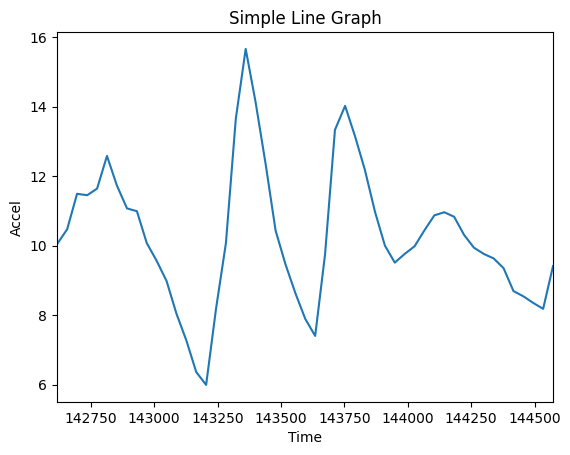

In [27]:
import matplotlib.pyplot as plt

test_ls = [test.label for test in tests]

for i in range(1, len(tests)+1):
    print(f"{i}. {tests[i-1].label}")

test_num = input(f"choose from the following tests:")
test_num = int(test_num)-1

# 1. Prepare data for x and y axes
y = [i.acceleration for i in tests[test_num].datapoints]
x = [i.timestamp for i in tests[test_num].datapoints]

# 2. Create the line plot
plt.plot(x, y)
x_min = min(x)
x_max = max(x)
plt.xlim(x_min, x_max)

# 3. Add titles and labels
plt.title("Simple Line Graph")
plt.ylabel("Accel")
plt.xlabel("Time")

# 4. Display the graph
plt.show()
